<h1> Section 1: Customer Behavior Analysis & AI-driven Insights</h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from nltk.sentiment.vader import SentimentIntensityAnalyzer


In [2]:
df = pd.read_csv("./customers_5000.csv")

In [3]:
df.head()

,Customer_ID,Booking_Frequency,Avg_Spending,Preferred_Service,Review_Text,Last_Activity
0,CUST00001,10,170.85,Massage,Service quality was acceptable but not outstan...,2026-03-07
1,CUST00002,6,180.24,Spa,The service quality was excellent. The cost ma...,2026-01-01
2,CUST00003,11,144.47,Makeup,NaN,2026-01-29
3,CUST00004,27,NaN,Spa,Pricing was standard compared to similar place...,2025-12-21
4,CUST00005,5,84.07,Hair Coloring,Cleanliness was acceptable overall. The schedu...,2025-10-25


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        5000 non-null   object 
 1   Booking_Frequency  5000 non-null   int64  
 2   Avg_Spending       4800 non-null   float64
 3   Preferred_Service  4869 non-null   object 
 4   Review_Text        4695 non-null   object 
 5   Last_Activity      5000 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 234.5+ KB


In [5]:
df["Days_Since_Last_Visit"] =  df["Last_Activity"].apply(lambda x : (datetime.now() - (datetime.strptime(x, "%Y-%m-%d"))).days)

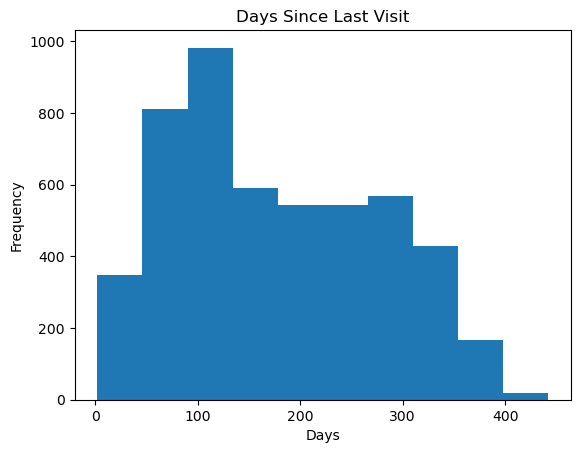

In [6]:
plt.hist(df["Days_Since_Last_Visit"])
plt.title("Days Since Last Visit")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

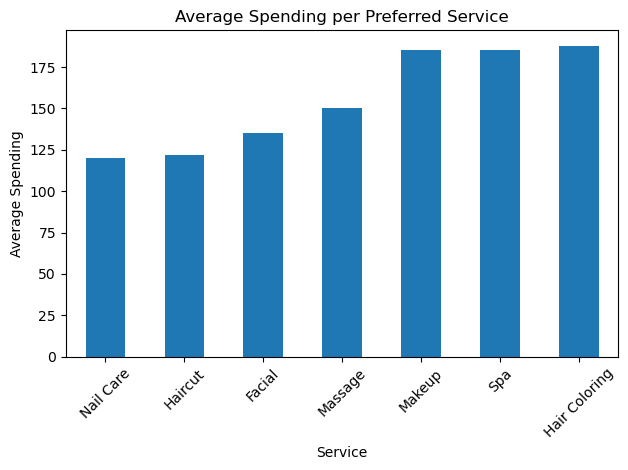

In [7]:
avg_spending = df.groupby("Preferred_Service")["Avg_Spending"].mean().sort_values()
plt.figure()
avg_spending.plot(kind="bar")
plt.title("Average Spending per Preferred Service")
plt.xlabel("Service")
plt.ylabel("Average Spending")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

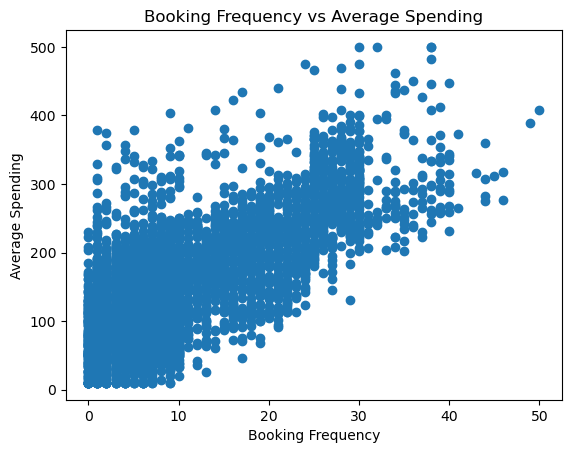

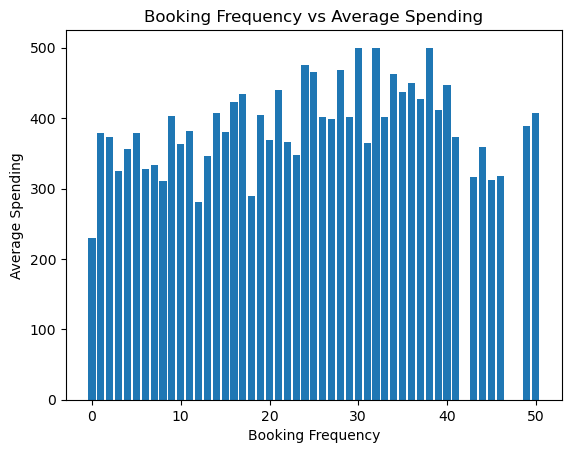

In [8]:
plt.scatter(df["Booking_Frequency"], df["Avg_Spending"])
plt.title("Booking Frequency vs Average Spending")
plt.xlabel("Booking Frequency")
plt.ylabel("Average Spending")
plt.show()
plt.bar(df["Booking_Frequency"], df["Avg_Spending"])
plt.title("Booking Frequency vs Average Spending")
plt.xlabel("Booking Frequency")
plt.ylabel("Average Spending")
plt.show()


<h2>Handling Null Values</h2>

In [9]:
#handle textual null values by filling them with an empty string.
df["Preferred_Service"] = df["Preferred_Service"].fillna("")
df["Review_Text"] = df["Review_Text"].fillna("")

In [10]:
#for average spending we use the median of the column multiplied by a normalized value of booking frequency

median_spending = df["Avg_Spending"].median()
mask = df["Avg_Spending"].isna()

df.loc[mask, "Avg_Spending"] = (
    median_spending *
    (1 +  df.loc[mask, "Booking_Frequency"]/100) 
)

<h2>Sentiment Analysis on the reviews</h2>

In [11]:
#For sentiment analysis we will just use the nltk sentiment analysis vader model for this use case
sia = SentimentIntensityAnalyzer()
scores = []
for i, row in tqdm.tqdm(df.iterrows(), total= len(df)):
    score = {"compound":sia.polarity_scores(row["Review_Text"])["compound"]}
    scores.append(score)

100%|██████████| 5000/5000 [00:00<00:00, 6015.72it/s]


In [12]:
scores_df = pd.DataFrame(scores)
df = df.join(scores_df)

<h2>Clustering and Analysis</h2>

K-Means on **standardized** features; **k = 3** is chosen from the elbow curve (inertia for k = 2 … 9). Three segments balance interpretability with the elbow shape versus finer four-way splits.

In [13]:
features = [
    "Booking_Frequency",
    "Avg_Spending",
    "compound",
    "Days_Since_Last_Visit",
]

scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[features])

c:\Users\Lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^

Text(0.5, 1.0, 'Elbow curve (standardized features)')

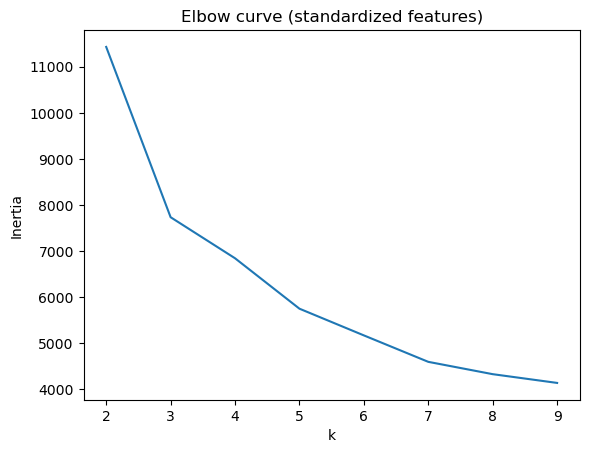

In [14]:
inertia = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_cluster)
    inertia.append(km.inertia_)

plt.plot(range(2, 10), inertia)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow curve (standardized features)")

In [15]:
# k=3: chosen from plot above.
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init="auto",
)

df["cluster"] = kmeans.fit_predict(X_cluster)

c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


In [16]:
"""
Cluster 0 — Engaged regulars: Moderate frequency (7 bookings) and spend ($164), strong positive 
sentiment (compound 0.77), and fairly recent activity (~98 days).
Cluster 1 — High-frequency, disengaged: High booking frequency (24) but neutral sentiment (compound ~0.0) and notably less recent activity. 
These customers book often but sentiment has dropped — a watch group.
Cluster 2 — Low-value inactives: Low frequency (5.7), low spend ($98), mild positive sentiment, and extended inactivity (~237 days). 
Moderate churn risk.
Cluster 3 — Premium champions: Highest spend ($267), high frequency (23), strongest positive sentiment (compound 0.79), and the most recent activity (~76 days). 
The core high-value segment.
Cluster 4 — At-risk / churned: Lowest spend ($82), low frequency (5.8), clearly negative sentiment (compound -0.48), and the longest inactivity (~306 days). 
Highest churn risk.
"""

print(df.groupby("cluster")[features].median())
print(df.groupby("cluster")[features].mean())

         Booking_Frequency  Avg_Spending  compound  Days_Since_Last_Visit
cluster                                                                  
0                      7.0        164.40    0.7650                   99.0
1                     24.0        214.75    0.0000                  203.0
2                      5.0         97.03    0.2023                  236.0
3                     23.0        266.99    0.7906                   77.0
4                      5.0         76.22   -0.5200                  307.0
         Booking_Frequency  Avg_Spending  compound  Days_Since_Last_Visit
cluster                                                                  
0                 6.909366    166.473864  0.673158              99.945015
1                25.110870    221.714336  0.008126             199.163043
2                 5.735270     97.504200  0.250241             237.643983
3                23.241830    276.858119  0.715575              77.618301
4                 5.777049     81.9925

<h2>Rule Based Metrics</h2>

In [17]:
high_value = df[
    (df["Avg_Spending"] > df["Avg_Spending"].quantile(0.75)) &
    (df["Booking_Frequency"] > df["Booking_Frequency"].quantile(0.75))
]

In [18]:
high_value.cluster.value_counts()

cluster
3    609
1    236
Name: count, dtype: int64

In [19]:
df["churn_risk"] = (
    (df["Days_Since_Last_Visit"] > 90).astype(int) +
    (df["compound"] < -0.3).astype(int)
)

In [20]:
df["risk_level"] = pd.cut(
    df["churn_risk"],
    bins=[-1,0,1,2],
    labels=["Low","Medium","High"]
)
df.drop(columns=["churn_risk"],inplace=True)

In [21]:
df.groupby(["cluster"])["risk_level"].value_counts().to_frame().T

cluster         0                1               2             3              \
risk_level Medium  Low High Medium High Low Medium High Low  Low Medium High   
count         987  665    3    342  102  16   1186   17   2  472    293    0   

cluster       4             
risk_level High Medium Low  
count       722    193   0

<h1>Section 2: AI-powered Personalization Model</h1>

In [22]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pickle


In [23]:
df = pd.read_csv("customer_history.csv")
df.head()

,History_ID,Customer_ID,Service,Booking_Date,Amount_Spent
0,HIST000001,CUST00001,Massage,2024-09-14,169.66
1,HIST000002,CUST00001,Massage,2024-11-15,154.56
2,HIST000003,CUST00001,Spa,2025-01-10,167.15
3,HIST000004,CUST00001,Massage,2025-03-17,162.43
4,HIST000005,CUST00001,Aromatherapy,2025-04-26,283.16


<h2>Train, Test Split</h2>

In [24]:
def train_test_split(df, test_size=0.2):
    test = df.groupby("Customer_ID").sample(frac=test_size, random_state=42)
    train = df.drop(test.index)
    return train, test

train_df, test_df = train_test_split(df)

In [25]:
#use train dataset for evaluation metrics
train_user_item = train_df.pivot_table(
    index="Customer_ID",
    columns="Service",
    values="Amount_Spent",
    aggfunc="sum"
).fillna(0)

#user entire dataset for recommendation model
user_item = train_df.pivot_table(
    index="Customer_ID",
    columns="Service",
    values="Amount_Spent",
    aggfunc="sum"
).fillna(0)

In [26]:
#Train the SVD on the training data
svd = TruncatedSVD(n_components=7)
latent_matrix = svd.fit_transform(train_user_item)
collab_sim = cosine_similarity(latent_matrix)

<h2>Generate Recommendations</h2>

In [27]:
def recommend(customer_id, user_item, collab_sim, top_n=3):
    if customer_id not in user_item.index:
        return []
    idx = list(user_item.index).index(customer_id)

    similar_users = collab_sim[idx].argsort()[::-1][1:6]
    scores = user_item.iloc[similar_users].mean()

    user_services = user_item.loc[customer_id]
    # include for recommendations for services not tried by users
    # scores = scores[user_services == 0] 
    return list(scores.sort_values(ascending=False).head(top_n).index)

<h2>Evaluation Metrics</h2>

In [28]:
def precision_recall_at_k(train_ui, test_df, collab_sim, k=1):
    precisions = []
    recalls = []

    for user in test_df["Customer_ID"].unique():
        actual = set(test_df[test_df["Customer_ID"] == user]["Service"])

        predicted = set(recommend(user, train_ui, collab_sim, top_n=k))

        if len(predicted) == 0:
            continue

        precision = len(actual & predicted) / len(predicted)
        recall = len(actual & predicted) / len(actual)

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)

In [29]:
def mse_on_test(train_ui, test_df, svd_model):
    """
    Evaluate reconstruction error on held-out test interactions.
    Uses only existing workflow artifacts: train user-item matrix, test dataframe, and trained SVD.
    """
    reconstructed = svd_model.inverse_transform(svd_model.transform(train_ui))
    pred_df = pd.DataFrame(reconstructed, index=train_ui.index, columns=train_ui.columns)

    y_true = []
    y_pred = []

    for _, row in test_df.iterrows():
        user = row["Customer_ID"]
        service = row["Service"]
        if user in pred_df.index and service in pred_df.columns:
            y_true.append(row["Amount_Spent"])
            y_pred.append(pred_df.loc[user, service])

    return mean_squared_error(y_true, y_pred)

In [30]:
precision, recall = precision_recall_at_k(train_user_item, test_df, collab_sim)

print("Precision@K:", precision)
print("Recall@K:", recall)

Precision@K: 0.9305820610687023
Recall@K: 0.7568622773536895


In [31]:
mse_value = mse_on_test(train_user_item, test_df, svd)
print("MSE:", mse_value)

MSE: 9084969.936894871


<h2>Export The Model</h2>

In [32]:
svd = TruncatedSVD(n_components=7)
latent_matrix = svd.fit_transform(user_item)
collab_sim = cosine_similarity(latent_matrix)
model_data = {
    "svd": svd,
    "user_item": user_item,
    "collab_sim": collab_sim
}

with open("recommendation_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

In [33]:
# with open("recommendation_model.pkl", "rb") as f:
#     model_data = pickle.load(f)

# svd = model_data["svd"]
# user_item = model_data["user_item"]
# collab_sim = model_data["collab_sim"]


<h1>AI Chatbot</h1>

In [34]:
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer
from transformers import AutoModelForSequenceClassification
from sklearn.preprocessing import LabelEncoder
import torch
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import torch
from transformers import  AutoTokenizer
from transformers import TrainingArguments, Trainer
from sklearn.preprocessing import LabelEncoder  

In [35]:
#Sentiment Analysis and Intent Analysis on BERT
intent_df = pd.read_csv("training_data_classification.csv")
intent_df.head()

,query,intent
0,"I want to reschedule instead of cancel, but if...",reschedule
1,Please help me reschedule my booking to 5:00 P...,reschedule
2,Can you cancel my scheduled facial at the nort...,cancellation
3,Please help me reschedule my booking to 3:30 P...,reschedule
4,Need a therapist at home in Sydney CBD for car...,booking


In [36]:
intent_df.shape

(25000, 2)

In [37]:
intent_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   query   25000 non-null  object
 1   intent  25000 non-null  object
dtypes: object(2)
memory usage: 390.8+ KB


In [38]:
intent_df["intent"].value_counts()

intent
reschedule       5000
cancellation     5000
booking          5000
pricing          5000
general_query    5000
Name: count, dtype: int64

<h2>Encode Labels</h2>

In [39]:
#Label Encoding for intent values
le = LabelEncoder()
intent_df["labels"] = le.fit_transform(intent_df["intent"])
le.classes_

# 2. Export (Save) the encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

<h2>Encode Queries</h2>

In [40]:

tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

In [41]:
dataset = intent_df[["query","labels"]]

In [42]:
def tokenize(example):
    return tokenizer(
        example["query"],
        padding="max_length",
        truncation=True,
        max_length=64
    )


<h2>Train, Test Split</h2>

In [43]:
tool_call_train, tool_call_test = train_test_split(dataset, test_size=0.2, train_size=0.8, random_state=42, shuffle=True)

tool_call_train = tool_call_train.reset_index(drop=True)
tool_call_test = tool_call_test.reset_index(drop=True)


train_dataset = Dataset.from_pandas(tool_call_train)
test_dataset  = Dataset.from_pandas(tool_call_test)


train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)



Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [44]:
# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",           # Directory for saving model checkpoints
    learning_rate=5e-5,              # Start with a small learning rate
    per_device_train_batch_size=16,  # Batch size per GPU
    per_device_eval_batch_size=16,
    num_train_epochs=3,              # Number of epochs
    weight_decay=0.01,               # Regularization
    save_total_limit=2,              # Limit checkpoints to save space
    logging_dir="./logs",            # Directory for logs
    logging_steps=100,               # Log every 100 steps
    fp16=True                        # Enable mixed precision for faster training
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


<h2>Model Training</h2>

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=len(le.classes_)) #Define BERT model on initial run
# model = AutoModelForSequenceClassification.from_pretrained("./intent-classifier-model/")
# tokenizer = AutoTokenizer.from_pretrained("./query-tokenizer/") #Define bert tokenizer on initialrun

trainer = Trainer(
    model=model,
    args=training_args,                 
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)
trainer.train()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
c:\Users\Lenovo\anaconda3\Lib\site-pa

Step,Training Loss
100,0.407585


In [ ]:
model.save_pretrained("./intent-classifier-model")
tokenizer.save_pretrained("./query-tokenizer")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.97it/s]


('./query-tokenizer\\tokenizer_config.json',
 './query-tokenizer\\tokenizer.json')

In [ ]:
predictions = trainer.predict(test_dataset)
predicted_labels = predictions.predictions.argmax(axis=-1)
print(classification_report(test_dataset["labels"], predicted_labels))

In [ ]:
text = "What service options do you have?"
encoded = tokenizer(text, return_tensors="pt")
with torch.no_grad():
    logits = model(**encoded).logits
    
predicted_class_id = logits.argmax().item()

le.classes_[predicted_class_id]

'pricing'